In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# create the data

n_per_cluster = 300
blur = 1

A = [1, 1]
B = [5, 1]
C = [4, 3]

a = np.random.randn(n_per_cluster, 2) * blur + A
b = np.random.randn(n_per_cluster, 2) * blur + B
c = np.random.randn(n_per_cluster, 2) * blur + C
data_np = np.vstack([a, b, c])
data = torch.from_numpy(data_np).float()

labels_np = np.array([0] * n_per_cluster + [1] * n_per_cluster + [2] * n_per_cluster)
labels = torch.from_numpy(labels_np).long()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.1, random_state=42, stratify=labels)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=test_dataset.tensors[0].shape[0], shuffle=False)

In [ ]:
def create_model_optimizer(optimizer_class, lr, **optimizer_kwargs):
    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(2, 8)
            self.fc2 = nn.Linear(8, 8)
            self.fc3 = nn.Linear(8, 3)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    model = Net()
    loss_fn = nn.CrossEntropyLoss()

    # We pass the learning rate and any other arguments (like betas for Adam or momentum for SGD)
    optimizer = optimizer_class(model.parameters(), lr=lr, **optimizer_kwargs)

    # apply learning decay

    return model, loss_fn, optimizer

In [5]:
def train_model(model, loss_fn, optimizer, train_loader, test_loader, epochs):
    losses = torch.zeros(epochs)
    train_acc = torch.zeros(epochs)
    test_acc = torch.zeros(epochs)

    for epoch in range(epochs):
        model.train()
        batch_acc = []
        batch_loss = []
        for X_batch, y_batch in train_loader:
            
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            batch_loss.append(loss.item())
            batch_acc_item = (outputs.argmax(dim=1) == y_batch).float().mean().item()
            batch_acc.append(batch_acc_item)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        losses[epoch] = np.mean(batch_loss)
        train_acc[epoch] = np.mean(batch_acc)

        model.eval()
        with torch.no_grad():
            X_test, y_test = next(iter(test_loader))
            test_outputs = model(X_test)
            predicted = test_outputs.argmax(dim=1)
            accuracy = (predicted == y_test).float().mean().item()
            test_acc[epoch] = accuracy
            
    return losses, train_acc, test_acc

In [ ]:
learning_rate = 0.001
momentum = 0.9
epochs = 50
beta1 = 0.9 # momentum
beta2 = 0.999
l2_lambda = np.linspace(0, 0.1, num=6)

acc_train_results = np.zeros((epochs, len(l2_lambda)))
acc_test_results = np.zeros((epochs, len(l2_lambda)))

for i, l2 in enumerate(l2_lambda):
    # in this cases we could use Adam or better AdamW, which decouples the weight decay from the optimization steps,
    #  but for simplicity we will use Adam with weight decay
    model, loss_fn, optimizer = create_model_optimizer(torch.optim.Adam, lr=learning_rate, betas=(beta1, beta2), weight_decay=l2)
    
    # Train and store in a dictionary
    losses, train_acc, test_acc = train_model(
        model, loss_fn, optimizer, train_loader, test_loader, epochs
    )
    acc_train_results[:, i] = train_acc
    acc_test_results[:, i] = test_acc

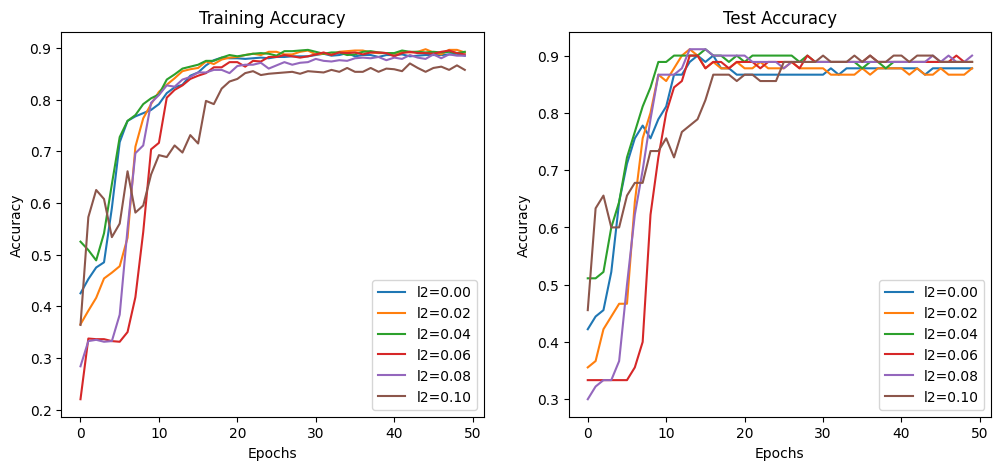

In [ ]:
# plot to compare the effect of weight decay on training and test accuracy
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(acc_train_results)
ax[0].set_title("Training Accuracy")
ax[0].legend([f"l2={l2:.2f}" for l2 in l2_lambda])
ax[0].set_xlabel("Epochs")
ax[0].set_ylabel("Accuracy")
ax[1].plot(acc_test_results)
ax[1].set_title("Test Accuracy")
ax[1].legend([f"l2={l2:.2f}" for l2 in l2_lambda])
ax[1].set_xlabel("Epochs")
ax[1].set_ylabel("Accuracy")
plt.show()

# the initial learning is slow since we are using a small learning rate. With ADAM optimizer, the effect of the initial learning rate
# doesn't have a huge impact on the final accuracy but it influences the speed of convergence.
# also in this picture we can see the model performs well without regularization, infact for models that are already performing well
# adding regularization can actually hurt performance, especially if the regularization strength is too high. This is because it can 
# constrain the model too much, preventing it from fitting the training data effectively.

In [35]:
# adding learning rate decay function
# this in principle will help the model to converge faster, since we start with a higher learning rate and then we decay it, 
# so we can make bigger steps at the beginning and then smaller steps as we get closer to the minimum. This can help to avoid 
# getting stuck in local minima and can also help to improve the final accuracy of the model.
def create_model_optimizer(optimizer_class, lr, gamma=None, stepsize=None, **optimizer_kwargs):
    class Net(nn.Module):
        def __init__(self):
            super(Net, self).__init__()
            self.fc1 = nn.Linear(2, 8)
            self.fc2 = nn.Linear(8, 8)
            self.fc3 = nn.Linear(8, 3)

        def forward(self, x):
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

    model = Net()
    loss_fn = nn.CrossEntropyLoss()
    
    # We pass the learning rate and any other arguments (like betas for Adam or momentum for SGD)
    optimizer = optimizer_class(model.parameters(), lr=lr, **optimizer_kwargs)

    # apply learning decay
    # 2. Optional Scheduler Logic
    scheduler = None
    if gamma is not None and stepsize is not None:
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=stepsize, gamma=gamma)
    # gamma is the factor by which the learning rate will be reduced. new_lr = lr * gamma

    return model, loss_fn, optimizer, scheduler

In [27]:
def train_model(model, loss_fn, optimizer, train_loader, test_loader, epochs, dynamic_lr=False, scheduler=None):
    losses = torch.zeros(epochs)
    train_acc = torch.zeros(epochs)
    test_acc = torch.zeros(epochs)

    for epoch in range(epochs):
        model.train()
        batch_acc = []
        batch_loss = []
        for X_batch, y_batch in train_loader:
            
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)

            batch_loss.append(loss.item())
            batch_acc_item = (outputs.argmax(dim=1) == y_batch).float().mean().item()
            batch_acc.append(batch_acc_item)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            if dynamic_lr:
                scheduler.step()

        losses[epoch] = np.mean(batch_loss)
        train_acc[epoch] = np.mean(batch_acc)

        model.eval()
        with torch.no_grad():
            X_test, y_test = next(iter(test_loader))
            test_outputs = model(X_test)
            predicted = test_outputs.argmax(dim=1)
            accuracy = (predicted == y_test).float().mean().item()
            test_acc[epoch] = accuracy
            
    return losses, train_acc, test_acc

In [30]:
model, loss_fn, optimizer, scheduler = create_model_optimizer(torch.optim.SGD, lr=0.01, stepsize=5, gamma=0.5)

# if stepsize = batch_size * len(train_loader) then we decay the learning rate after each epoch
for epoch in range(3):
    for batch in range(10):
        print(f"Epoch {epoch}, Batch {batch}, Learning Rate: {optimizer.param_groups[0]['lr']}")
        scheduler.step()

Epoch 0, Batch 0, Learning Rate: 0.01
Epoch 0, Batch 1, Learning Rate: 0.01
Epoch 0, Batch 2, Learning Rate: 0.01
Epoch 0, Batch 3, Learning Rate: 0.01
Epoch 0, Batch 4, Learning Rate: 0.01
Epoch 0, Batch 5, Learning Rate: 0.005
Epoch 0, Batch 6, Learning Rate: 0.005
Epoch 0, Batch 7, Learning Rate: 0.005
Epoch 0, Batch 8, Learning Rate: 0.005
Epoch 0, Batch 9, Learning Rate: 0.005
Epoch 1, Batch 0, Learning Rate: 0.0025
Epoch 1, Batch 1, Learning Rate: 0.0025
Epoch 1, Batch 2, Learning Rate: 0.0025
Epoch 1, Batch 3, Learning Rate: 0.0025
Epoch 1, Batch 4, Learning Rate: 0.0025
Epoch 1, Batch 5, Learning Rate: 0.00125
Epoch 1, Batch 6, Learning Rate: 0.00125
Epoch 1, Batch 7, Learning Rate: 0.00125
Epoch 1, Batch 8, Learning Rate: 0.00125
Epoch 1, Batch 9, Learning Rate: 0.00125
Epoch 2, Batch 0, Learning Rate: 0.000625
Epoch 2, Batch 1, Learning Rate: 0.000625
Epoch 2, Batch 2, Learning Rate: 0.000625
Epoch 2, Batch 3, Learning Rate: 0.000625
Epoch 2, Batch 4, Learning Rate: 0.000625


C:\Users\Pablo\AppData\Local\Temp\ipykernel_13520\3722767852.py:7: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


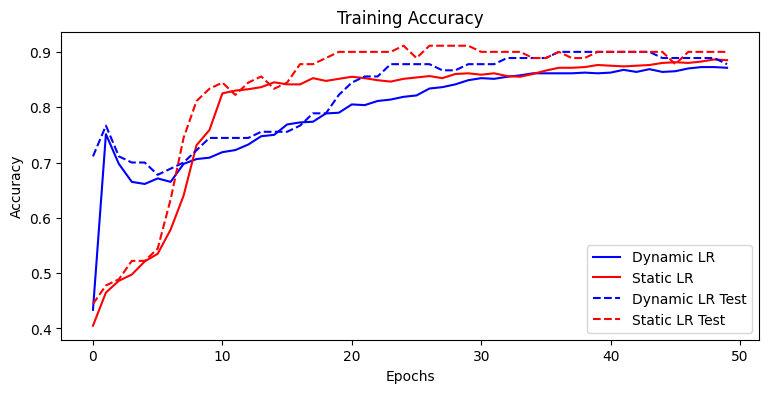

In [ ]:
# check dynamic vs static learning rate decay
lr = 0.01
epochs = 50

model_static, loss_fn_static, optimizer_static, _ = create_model_optimizer(torch.optim.SGD, lr=lr)
model_dynamic, loss_fn_dynamic, optimizer_dynamic, scheduler_dynamic = create_model_optimizer(torch.optim.SGD, lr=lr, stepsize=batch_size*len(train_loader), gamma=0.5)

experiment = {
    "dynamic_lr": train_model(model_dynamic, loss_fn_dynamic, optimizer_dynamic, train_loader, test_loader, epochs=epochs, dynamic_lr=True, scheduler=scheduler_dynamic),
    "static_lr": train_model(model_static, loss_fn_static, optimizer_static, train_loader, test_loader, epochs=epochs)
}

training_acc_dynamic = experiment["dynamic_lr"][1]
training_acc_static = experiment["static_lr"][1]
test_acc_dynamic = experiment["dynamic_lr"][2]
test_acc_static = experiment["static_lr"][2]

fig = plt.figure(figsize=(9, 4))
ax = fig.add_subplot(1, 1, 1)
ax.plot(training_acc_dynamic, label="Dynamic LR", color="blue")
ax.plot(training_acc_static, label="Static LR", color="red")
ax.plot(test_acc_dynamic, label="Dynamic LR Test", linestyle="dashed", color="blue")
ax.plot(test_acc_static, label="Static LR Test", linestyle="dashed", color="red")
ax.set_title("Training Accuracy")
ax.set_xlabel("Epochs")
ax.set_ylabel("Accuracy")
ax.legend()
plt.show()

# for this particular case there is not a clear difference between using dynamic or static learning rate decay, but in general using 
# a dynamic learning rate can help to converge faster and can also help to improve the final accuracy of the model.